<a href="https://colab.research.google.com/github/altairmurat/pythonsession1probstats/blob/main/Session_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Session 1

## Part 1: Plotting of PMF & CDF of Dicrete Random Variable Distribution.

###Code

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from abc import ABC, abstractmethod
from ipywidgets import interact, IntSlider
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
class Distribution(ABC):
    def __init__(self, name="Generic Distribution"):
        self.name = name
        self.mc_data = np.array([])

        # Track limits for graph drawing
        self.x_min = 0
        self.x_max = 0
        self.y_max = 0.0

    def save_results(self, results):
        """Appends Monte Carlo results and dynamically updates axis limits."""
        self.mc_data = np.append(self.mc_data, results)

        # Refresh x_max and x_min based on the new dataset
        if len(self.mc_data) > 0:
            self.x_min = int(np.min(self.mc_data))
            self.x_max = int(np.max(self.mc_data))

            # To estimate y_max (highest probability density) we can look at the mode
            # This is a rough estimation for dynamic scaling
            values, counts = np.unique(self.mc_data, return_counts=True)
            self.y_max = np.max(counts) / len(self.mc_data)

    def clear_results(self):
        """Clears stored simulation data and resets limits."""
        self.mc_data = np.array([])
        self.x_min = 0
        self.x_max = 0
        self.y_max = 0.0

    @abstractmethod
    def simulate(self, n_trials):
        pass

    def support_start(self):
      """
      Left boundary of the support for summation in CDF.
      Override this in subclasses when needed.
      """
      return 0

    def has_pmf(self):
      return type(self).pmf is not Distribution.pmf

    def has_cdf(self):
      return type(self).cdf is not Distribution.cdf

    @abstractmethod
    def pmf(self, k):
      """
      Default PMF:
      if subclass did not implement PMF directly, try deriving it from CDF.
      """

      return self.FromCdf_ToPmf(k)


    @abstractmethod
    def cdf(self, k):
      """
      Default CDF:
      if subclass did not implement CDF directly, try deriving it from PMF.
      """

      return self.FromPmf_ToCdf(k)


    def FromCdf_ToPmf(self, k):
      if not self.has_cdf():
        raise NotImplementedError(f"{self.name}: cannot derive PMF because CDF is not implemented.")

      if int(k) != k:
        return 0.0

      k = int(k)
      return self.cdf(k) - self.cdf(k - 1)

    def FromPmf_ToCdf(self, k):
      if not self.has_pmf():
        raise NotImplementedError(f"{self.name}: cannot derive CDF because PMF is not implemented.")

      if k < self.support_start():
        return 0.0

      k = int(np.floor(k))
      start = self.support_start()
      return sum(self.pmf(x) for x in range(start, k + 1))


    def plot_pmf(self, show_theoretical=True):
      has_data = len(self.mc_data) > 0

      # FIX: Only require PMF/CDF if we are actually drawing the theoretical line
      if show_theoretical and not self.has_pmf() and not self.has_cdf():
        raise NotImplementedError(f"{self.name}: Neither PMF nor CDF is implemented.")

      # Safety check: If we have no math AND no data, we can't draw anything!
      if not show_theoretical and not has_data:
        raise ValueError(f"{self.name}: Run simulate() first, or set show_theoretical=True")

      """Draws the Probability Mass Function (Histogram vs Curve)."""
      fig, ax = plt.subplots(figsize=(8, 5))

      has_data = len(self.mc_data) > 0
      plot_x_min = self.x_min if has_data else self.support_start()
      plot_x_max = self.x_max if has_data else self.support_start() + 20

      if has_data:
          bins = np.arange(plot_x_min, plot_x_max + 2) - 0.5
          ax.hist(self.mc_data, bins=bins, density=True, alpha=0.6,
                  color='steelblue', edgecolor='black', label='Monte Carlo Data')

      if show_theoretical:
          x_vals = np.arange(plot_x_min, plot_x_max + 1)
          y_vals = [self.pmf(x) for x in x_vals]
          ax.plot(x_vals, y_vals, 'ro-', markersize=5, label='Theoretical PMF', linewidth=2)

          if self.y_max == 0 and len(y_vals) > 0 and max(y_vals) > 0:
            ax.set_ylim(0, max(y_vals) * 1.2)

      # Utilize the saved y_max to add some padding to the top of the graph
      if self.y_max > 0:
          ax.set_ylim(0, self.y_max * 1.2)

      ax.set_title(f"{self.name} - PMF")
      ax.set_xlabel("Value")
      ax.set_ylabel("Probability")
      ax.legend()
      ax.grid(axis='y', alpha=0.4)
      plt.tight_layout()
      plt.show()


    def plot_cdf(self, show_theoretical=True):
      has_data = len(self.mc_data) > 0

      # FIX: Only require CDF/PMF if we are actually drawing the theoretical line
      if show_theoretical and not self.has_cdf() and not self.has_pmf():
        raise NotImplementedError(f"{self.name}: neither CDF nor PMF is implemented.")

      # Safety check
      if not show_theoretical and not has_data:
        raise ValueError(f"{self.name}: Run simulate() first, or set show_theoretical=True")

      fig, ax = plt.subplots(figsize=(8, 5))

      has_data = len(self.mc_data) > 0
      plot_x_min = self.x_min if has_data else self.support_start()
      plot_x_max = self.x_max if has_data else self.support_start() + 20

      if has_data:
          x_data = np.sort(self.mc_data)
          y_data = np.arange(1, len(x_data) + 1) / len(x_data)

          ax.step(x_data, y_data, where='post', label='Empirical CDF', color='steelblue', linewidth=2)

      if show_theoretical:
          x_vals = np.arange(plot_x_min, plot_x_max + 1)
          y_vals = [self.cdf(x) for x in x_vals]

          ax.step(x_vals, y_vals, where='post', label='Theoretical CDF', color='red', linestyle='--', linewidth=2)

      ax.set_title(f"{self.name} - CDF")
      ax.set_xlabel("Value")
      ax.set_ylabel("Cumulative Probability")
      ax.set_ylim(0, 1.05)
      ax.legend()
      ax.grid(axis='both', alpha=0.4)
      plt.tight_layout()
      plt.show()


    # Calculuating some statistics (from ChatGPT)
    def empirical_stats(self):
      if len(self.mc_data) == 0:
        raise ValueError(f"{self.name}: No simulation data available.")

      mean = np.mean(self.mc_data)
      var = np.var(self.mc_data)
      std = np.std(self.mc_data)

      # Avoid division by zero
      if std == 0:
        skew = 0.0
      else:
        skew = np.mean(((self.mc_data - mean) / std) ** 3)

      return {
        "mean": mean,
        "variance": var,
        "skewness": skew
      }

    def theoretical_stats(self):
      raise NotImplementedError(f"{self.name}: theoretical stats not implemented.")

    def compare_stats(self):
      emp = self.empirical_stats()

      print(f"\n{self.name} Statistics Comparison")
      print("-" * 45)

      try:
        theo = self.theoretical_stats()

        print(f"{'Metric':<12} {'Empirical':<15} {'Theoretical':<15}")
        print("-" * 45)

        for key in emp:
          print(f"{key:<12} {emp[key]:<15.5f} {theo[key]:<15.5f}")

      except NotImplementedError:
        print("Theoretical stats not available.\n")
        for key in emp:
          print(f"{key:<12}: {emp[key]:.5f}")

    def stats_table(self):
      emp = self.empirical_stats()

      try:
        theo = self.theoretical_stats()
        df = pd.DataFrame({
          "Empirical": emp,
          "Theoretical": theo
        })
      except NotImplementedError:
        df = pd.DataFrame({
          "Empirical": emp
        })

      return df

In [ ]:
class DiscreteUniformDistribution(Distribution):
    def __init__(self, a, b):
        super().__init__(name=f"DiscreteUniform(a={a}, b={b})")
        self.a = a
        self.b = b

    def support_start(self):
        return self.a

    def simulate(self, n_trials):
        results = np.random.randint(self.a, self.b + 1, size=n_trials)
        self.save_results(results)
        return results

    def pmf(self, k):
        if int(k) != k:
            return 0.0

        k = int(k)
        if self.a <= k <= self.b:
            return 1 / (self.b - self.a + 1)
        return 0.0

    def cdf(self, k):
      return self.FromPmf_ToCdf(k)


    # Calculating stats
    def theoretical_stats(self):
      mean = (self.a + self.b) / 2
      var = ((self.b - self.a + 1)**2 - 1) / 12
      skew = 0.0

      return {
        "mean": mean,
        "variance": var,
        "skewness": skew
      }

In [ ]:
class BinomialDistribution(Distribution):
    def __init__(self, n, p):
        super().__init__(name=f"Binomial(n={n}, p={p})")
        self.n = n
        self.p = p

    def simulate(self, n_trials):
      results = np.random.binomial(self.n, self.p, size=n_trials)
      self.save_results(results)
      return results

    def pmf(self, k):
      if k < 0 or k > self.n or int(k) != k:
        return 0.0

      k = int(k)
      return math.comb(self.n, k) * (self.p ** k) * ((1 - self.p) ** (self.n - k))

    def cdf(self, k):
        """Theoretical CDF: Sum of PMFs up to k."""
        if k < 0:
            return 0
        if k >= self.n:
            return 1

        # Sum the PMF for all integers from 0 up to floor(k)
        return sum(self.pmf(i) for i in range(int(k) + 1))


    # Calculating stats
    def theoretical_stats(self):
      mean = self.n * self.p
      var = self.n * self.p * (1 - self.p)

      if var == 0:
        skew = 0.0
      else:
        skew = (1 - 2 * self.p) / math.sqrt(var)

      return {
        "mean": mean,
        "variance": var,
        "skewness": skew
      }

In [ ]:
class GeometricDistribution(Distribution):
  def __init__(self, p):
    super().__init__(name=f"Geometric(p={p})")
    self.p = p

  def support_start(self):
     return 1

  def simulate(self, n_trials):
    results = np.random.geometric(self.p, size=n_trials)
    self.save_results(results)
    return results

  def pmf(self, k):
    if k < 1 or int(k) != k:
      return 0.0

    k = int(k)
    return ((1 - self.p) ** (k - 1)) * self.p

  def cdf(self, k):
    if k < 1:
      return 0.0

    k = int(np.floor(k))
    return 1 - ((1 - self.p) ** k)


  # Calculating stats
  def theoretical_stats(self):
    mean = 1 / self.p
    var = (1 - self.p) / (self.p ** 2)

    if var == 0:
      skew = 0.0
    else:
      skew = (2 - self.p) / math.sqrt((1 - self.p))

    return {
      "mean": mean,
      "variance": var,
      "skewness": skew
    }

In [ ]:
class NegativeBinomialDistribution(Distribution):
    def __init__(self, r, p):
        super().__init__(name=f"NegativeBinomial(r={r}, p={p})")
        self.r = r
        self.p = p

    def support_start(self):
        return self.r

    def simulate(self, n_trials):
        failures = np.random.negative_binomial(self.r, self.p, size=n_trials)
        results = failures + self.r
        self.save_results(results)
        return results

    def pmf(self, k):
        if k < self.r or int(k) != k:
            return 0.0

        k = int(k)
        return math.comb(k - 1, self.r - 1) * (self.p ** self.r) * ((1 - self.p) ** (k - self.r))

    def cdf(self, k):
      return self.FromPmf_ToCdf(k)

    # Calculating stats
    def theoretical_stats(self):
      mean = self.r / self.p
      var = self.r * (1 - self.p) / (self.p ** 2)

      if var == 0:
        skew = 0.0
      else:
        skew = (2 - self.p) / math.sqrt(self.r * (1 - self.p))

      return {
        "mean": mean,
        "variance": var,
        "skewness": skew
      }


In [ ]:
class HypergeometricDistribution(Distribution):
    def __init__(self, N, K, n):
        super().__init__(name=f"Hypergeometric(N={N}, K={K}, n={n})")
        self.N = N
        self.K = K
        self.n = n

    def support_start(self):
        return max(0, self.n - (self.N - self.K))

    def simulate(self, n_trials):
        results = np.random.hypergeometric(self.K, self.N - self.K, self.n, size=n_trials)
        self.save_results(results)
        return results

    def pmf(self, k):
        if int(k) != k:
            return 0.0

        k = int(k)

        lower = max(0, self.n - (self.N - self.K))
        upper = min(self.n, self.K)

        if k < lower or k > upper:
            return 0.0

        numerator = math.comb(self.K, k) * math.comb(self.N - self.K, self.n - k)
        denominator = math.comb(self.N, self.n)
        return numerator / denominator

    def cdf(self, k):
      return self.FromPmf_ToCdf(k)


    # Calculating stats
    def theoretical_stats(self):
      mean = self.n * (self.K / self.N)

      var = self.n * (self.K / self.N) * (1 - self.K / self.N) * ((self.N - self.n) / (self.N - 1))

      if var == 0:
        skew = 0.0
      else:
        num = (self.N - 2*self.K) * math.sqrt(self.N - 1) * (self.N - 2*self.n)
        den = math.sqrt(self.n * self.K * (self.N - self.K) * (self.N - self.n)) * (self.N - 2)
        skew = num / den

      return {
        "mean": mean,
        "variance": var,
        "skewness": skew
      }

In [ ]:
class NegativeHypergeometricDistribution(Distribution):
    """
    X = number of draws until the r-th success
    without replacement from a population of size N with K successes
    """
    def __init__(self, N, K, r):
        super().__init__(name=f"NegativeHypergeometric(N={N}, K={K}, r={r})")
        self.N = N
        self.K = K
        self.r = r

    def support_start(self):
        return self.r

    def simulate(self, n_trials):
        population = np.array([1] * self.K + [0] * (self.N - self.K))
        results = []

        for _ in range(n_trials):
            shuffled = np.random.permutation(population)
            cumulative_successes = np.cumsum(shuffled)
            draw_index = np.where(cumulative_successes == self.r)[0][0] + 1
            results.append(draw_index)

        results = np.array(results)
        self.save_results(results)
        return results

    def pmf(self, k):
        if int(k) != k:
            return 0.0

        k = int(k)

        lower = self.r
        upper = (self.N - self.K) + self.r

        if k < lower or k > upper:
            return 0.0

        numerator = math.comb(k - 1, self.r - 1) * math.comb(self.N - k, self.K - self.r)
        denominator = math.comb(self.N, self.K)
        return numerator / denominator

    def cdf(self, k):
      return self.FromPmf_ToCdf(k)


    # Calculating stats
    def theoretical_stats(self):
      mean = self.r * (self.N + 1) / (self.K + 1)

      var = (self.r * (self.N + 1) * (self.N - self.K) * (self.K - self.r + 1)) / \
        ((self.K + 1)**2 * (self.K + 2))

      # Skewness is messy → optional
      skew = np.nan

      return {
        "mean": mean,
        "variance": var,
        "skewness": skew
      }

In [ ]:
class PoissonDistribution(Distribution):
  def __init__(self, lam):
      super().__init__(name=f"Poisson(lambda={lam})")
      self.lam = lam

  def simulate(self, n_trials):
      results = np.random.poisson(self.lam, size=n_trials)
      self.save_results(results)
      return results

  def pmf(self, k):
      if k < 0 or int(k) != k:
          return 0.0

      k = int(k)
      return math.exp(-self.lam) * (self.lam ** k) / math.factorial(k)

  def cdf(self, k):
      return self.FromPmf_ToCdf(k)


  # Calculating stats
  def theoretical_stats(self):
    mean = self.lam
    var = self.lam

    if self.lam == 0:
      skew = 0.0
    else:
      skew = 1 / math.sqrt(self.lam)

    return {
      "mean": mean,
      "variance": var,
      "skewness": skew
    }

###Simulate pmfs and cdfs

Define the distribution
>dist = NameDistribution(param1,param2,...)

Run simulations
>dist.simulate(num_runs)

Plot the simulated pmf with or without the theoretical pmf
>dist.plot_pmf(show_theoretical=True)

Plot the simulated cdf with or without the theoretical cdf
>dist.plot_cdf(show_theoretical=True)

Compare simulated and theoretical means, variances, skewnesses
>dist.compare_stats()

###Available Distributions
>DiscreteUniformDistribution(a,b)

>BinomialDistribution(n,p)

>GeometricDistribution(p)

>NegativeBinomialDistribution(r,p)

>HypergeometricDistribution(N,K,n)

>NegativeHypergeometricDistribution(N,K,r)

>PoissonDistribution(lam)

X range: 1 to 6
Estimated Max Density: 0.2350


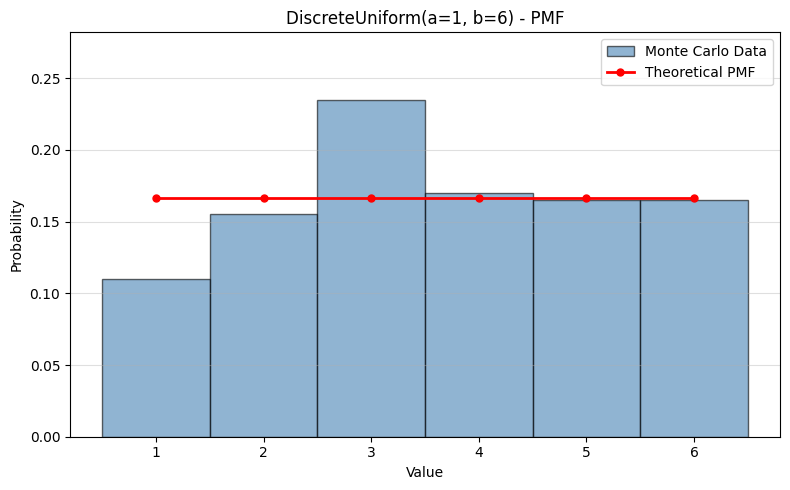

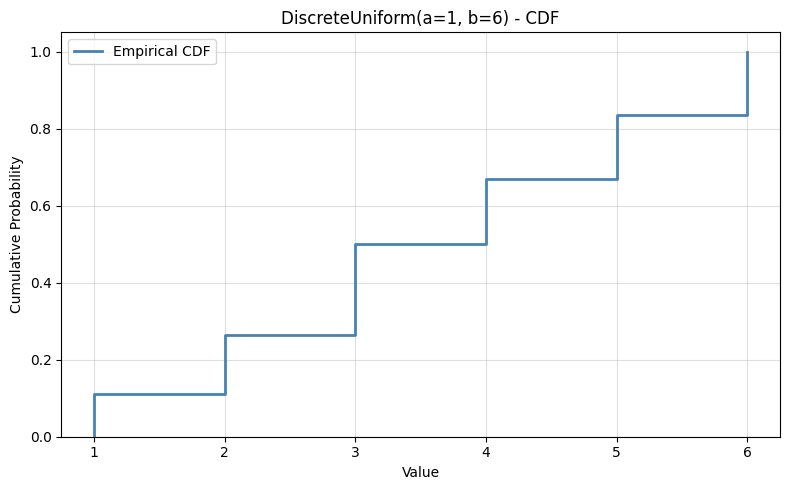


DiscreteUniform(a=1, b=6) Statistics Comparison
---------------------------------------------
Metric       Empirical       Theoretical    
---------------------------------------------
mean         3.62000         3.50000        
variance     2.52560         2.91667        
skewness     -0.00646        0.00000        


In [ ]:
# Create and simulate
unif = DiscreteUniformDistribution(a=1,b=6)
unif.simulate(200)

# Check the automatically refreshed limits!
print(f"X range: {unif.x_min} to {unif.x_max}")
print(f"Estimated Max Density: {unif.y_max:.4f}")

# Plot both
unif.plot_pmf(show_theoretical=True)
unif.plot_cdf(show_theoretical=False)
unif.compare_stats()

X range: 30 to 48
Estimated Max Density: 0.1402


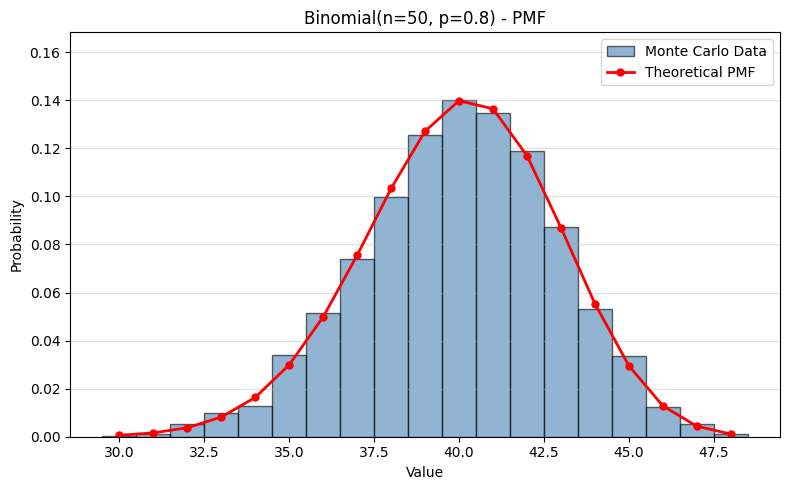

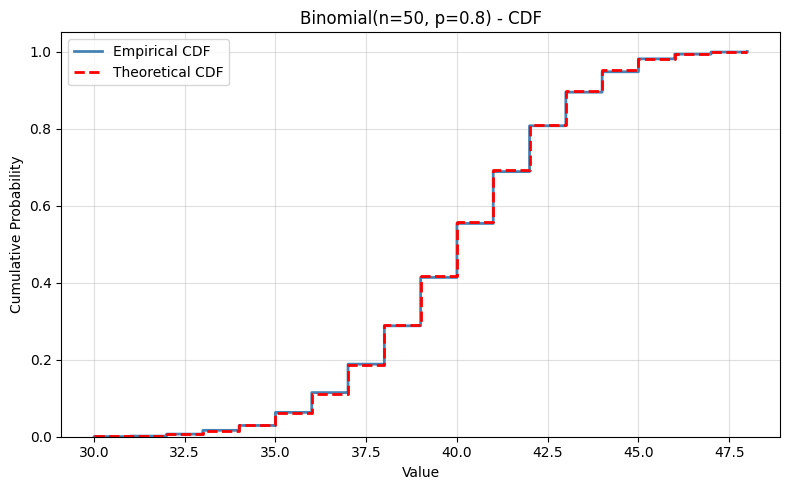


Binomial(n=50, p=0.8) Statistics Comparison
---------------------------------------------
Metric       Empirical       Theoretical    
---------------------------------------------
mean         40.01240        40.00000       
variance     8.12825         8.00000        
skewness     -0.20033        -0.21213       


In [ ]:
# Create and simulate
binom = BinomialDistribution(n=50, p=0.8)
binom.simulate(5000)

# Check the automatically refreshed limits!
print(f"X range: {binom.x_min} to {binom.x_max}")
print(f"Estimated Max Density: {binom.y_max:.4f}")

# Plot both
binom.plot_pmf(show_theoretical=True)
binom.plot_cdf(show_theoretical=True)
binom.compare_stats()

X range: 1 to 26
Estimated Max Density: 0.3116


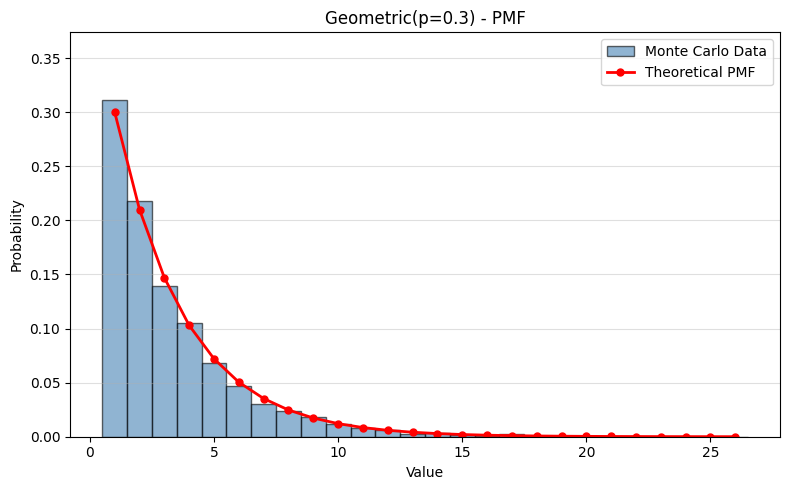

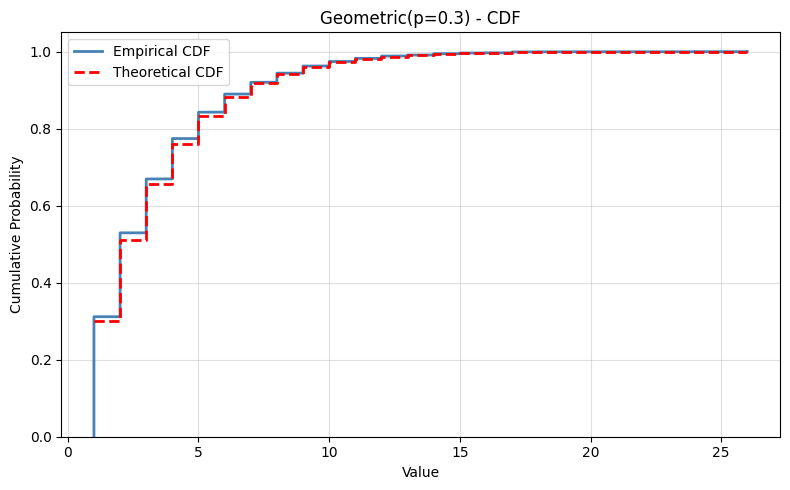

In [ ]:
# Create and simulate
geom = GeometricDistribution(0.3)
geom.simulate(5000)

# Check the automatically refreshed limits!
print(f"X range: {geom.x_min} to {geom.x_max}")
print(f"Estimated Max Density: {geom.y_max:.4f}")

# Plot both
geom.plot_pmf(show_theoretical=True)
geom.plot_cdf(show_theoretical=True)

X range: 326 to 486
Estimated Max Density: 0.0242


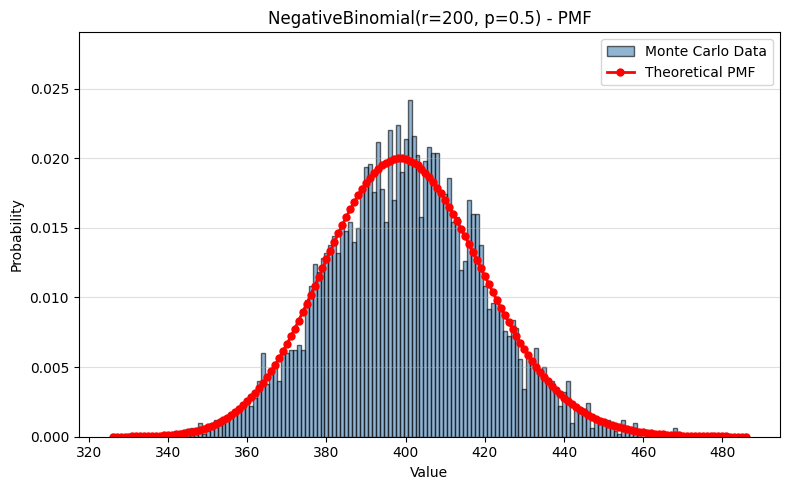

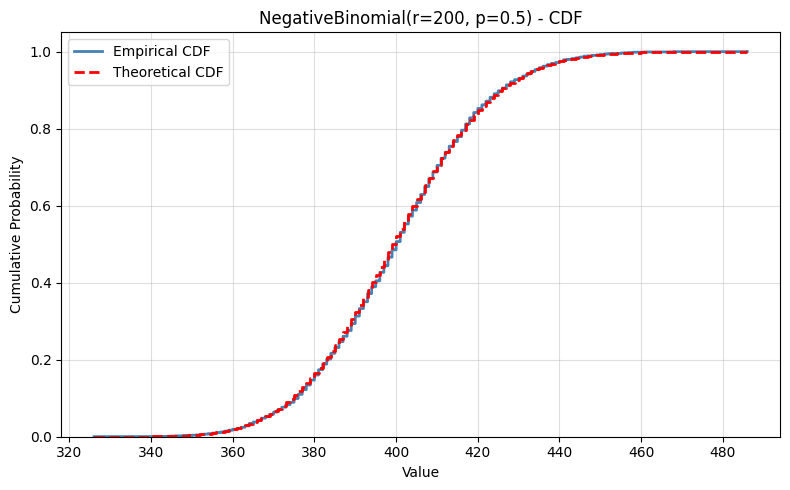


NegativeBinomial(r=200, p=0.5) Statistics Comparison
---------------------------------------------
Metric       Empirical       Theoretical    
---------------------------------------------
mean         400.29840       400.00000      
variance     390.99696       400.00000      
skewness     0.11357         0.15000        


In [ ]:
# Create and simulate
nbinom = NegativeBinomialDistribution(r=200,p=0.5)
nbinom.simulate(5000)

# Check the automatically refreshed limits!
print(f"X range: {nbinom.x_min} to {nbinom.x_max}")
print(f"Estimated Max Density: {nbinom.y_max:.4f}")

# Plot both
nbinom.plot_pmf(show_theoretical=True)
nbinom.plot_cdf(show_theoretical=True)
nbinom.compare_stats()

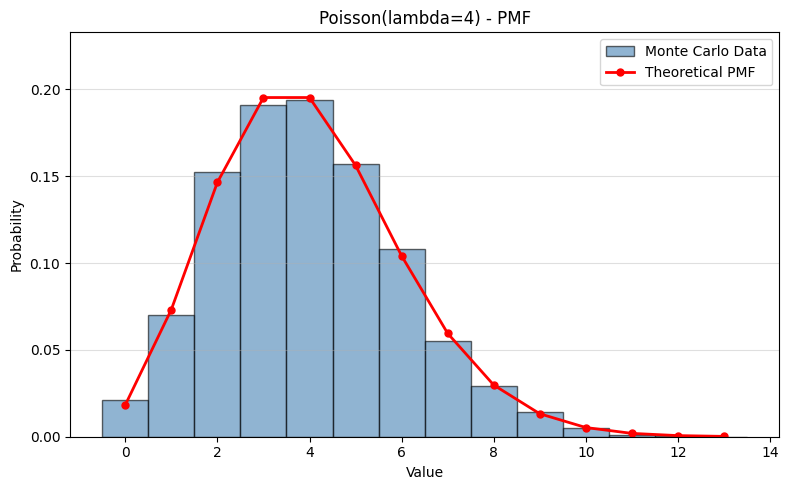

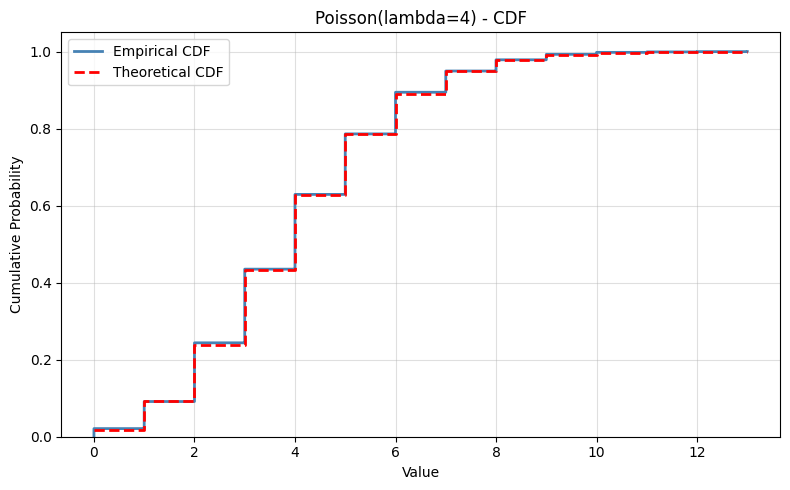

In [ ]:
pois = PoissonDistribution(4)
pois.simulate(10000)
pois.plot_pmf()
pois.plot_cdf()

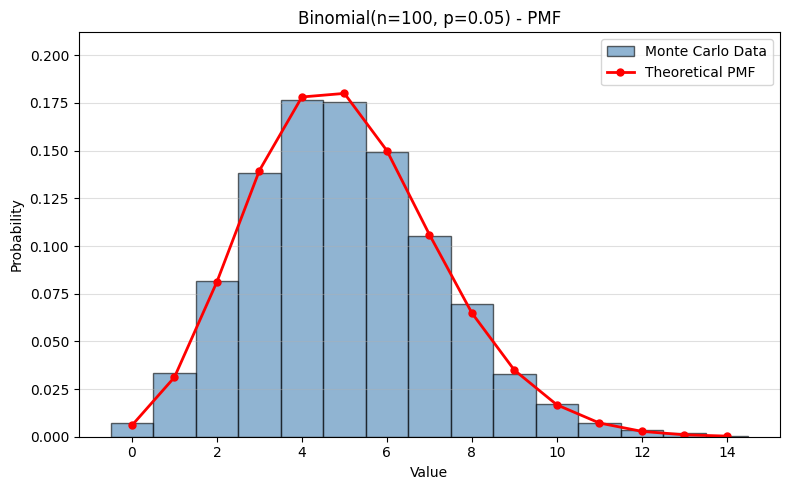

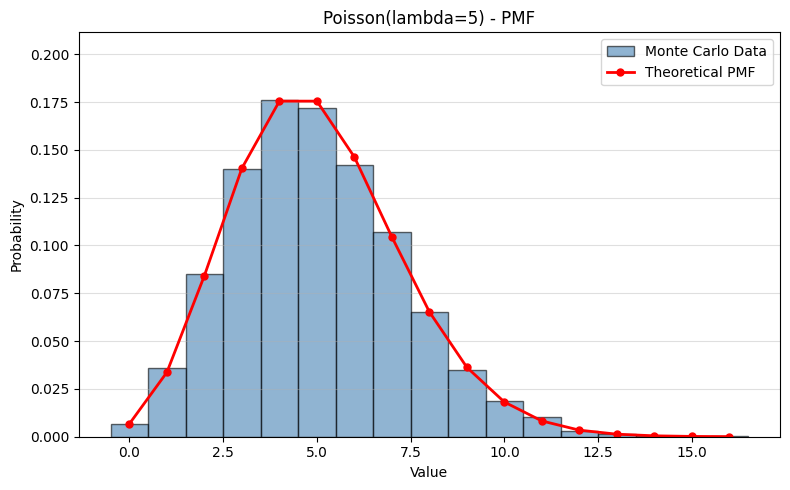

In [ ]:
binom = BinomialDistribution(n=100, p=0.05)
pois = PoissonDistribution(lam=5)

binom.simulate(10000)
pois.simulate(10000)

binom.plot_pmf()
pois.plot_pmf()


##Part 2 : Visualizations for the Birthday Paradox

In a room full of students, what is the probability that two or more have the same birthday?

> How many students are needed for this probability to be greater than 50%?

Before diving into the theoretical math, let's run a simulation using Python.

We will conduct a **Monte Carlo Simulation** to randomly assign birthdays to the students.

Then we calculate the frequency of having two or more students sharing their birthday.

Finally, we will introduce a random variable and perform analytic computations of its pmf to compare with the simulation.

### Step 1: Gathering Data through Simulation
Run the code below and use the slider to adjust the number of simulation runs.
The red dots will show the simulated probability of a shared birthday for each room size ($n$) from 1 to 60 people.

In [ ]:
class BirthdayDistribution(Distribution):
    def __init__(self):
        super().__init__(name="Birthday Paradox")

    def support_start(self):
        """
        It is impossible to have a shared birthday with only 1 person.
        The minimum number of people needed for a match is 2.
        """
        return 2

    def simulate(self, n_trials):
        """
        Simulates the Random Variable X:
        Number of people entering a room until a birthday is shared.
        """
        results = []
        for _ in range(n_trials):
            seen_birthdays = set()
            people_count = 0

            while True:
                people_count += 1
                bday = np.random.randint(1, 366) # Draw a random birthday

                if bday in seen_birthdays:
                    # Match found! Record how many people it took.
                    results.append(people_count)
                    break

                seen_birthdays.add(bday)

        # Use the base class method to store and update axes
        self.save_results(results)

    def cdf(self, k):
        return 0

    def pmf(self, k):
        return 0

def interactive_birthday_cdf(num_simulations):
    """
    This function runs every time the student moves the slider.
    """
    # 1. Create a fresh instance of our distribution
    birthday_dist = BirthdayDistribution()

    # 2. Run the simulation using the number of trials from the slider
    birthday_dist.simulate(num_simulations)

    # 3. Plot the CDF (The base class handles showing both empirical and theoretical!)
    birthday_dist.plot_cdf(show_theoretical=False)

# 4. Attach the slider to the function
print("Move the slider to see how the number of trials affects the accuracy of the Monte Carlo data!")
interact(interactive_birthday_cdf,
        num_simulations=IntSlider(min=10, max=1000, step=10, value=10, description='Runs:'))

Move the slider to see how the number of trials affects the accuracy of the Monte Carlo data!


interactive(children=(IntSlider(value=10, description='Runs:', max=1000, min=10, step=10), Output()), _dom_cla…

<function __main__.interactive_birthday_cdf(num_simulations)>

### Step 2: Defining the Random Variable and Formula

Now, let's mathematically prove the shape of the curve formed by the red dots above.

**1. Defining the Random Variable $X$**
* Let $X$ be the number of people that must enter a room until two share a birthday.
* What we are trying to find is the probability that a match occurs with $n$ people in the room, which is the Cumulative Distribution Function (CDF): **$P(X \le n)$**.

**2. Calculating Probability using the Complement**
Instead of directly calculating the probability of 'at least two people sharing a birthday,' it is much easier to calculate the probability that **'everyone has a unique birthday'** and subtract it from 1.
* The 1st person has a unique birthday: 365/365
* The 2nd person doesn't share with the 1st: 364/365
* ...
* The $n$-th person doesn't share with anyone before them: (365 - n + 1) / 365

Complete the function in the cell below to calculate the probability that $n$ people have unique birthdays, and then return the theoretical probability of a shared birthday!

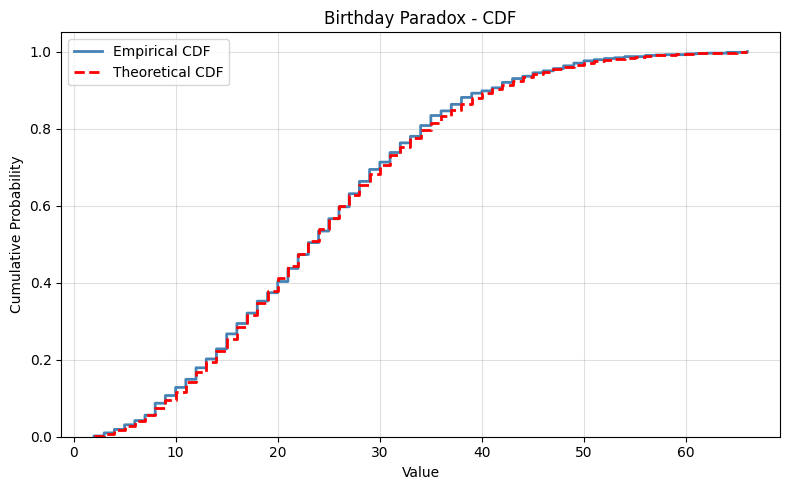

In [ ]:
def theoretical_cdf(self, k):
    """
    Theoretical CDF: P(X <= k)
    The probability that a match occurs at or before k people enter.
    """
    k = int(k)
    if k < 2:
        return 0.0
    if k > 365:
        return 1.0

    # Probability that all k people have DIFFERENT birthdays
    prob_no_match = math.prod((365 - i) / 365 for i in range(k))

    # P(Match) = 1 - P(No Match)
    return 1.0 - prob_no_match

def theoretical_pmf(self, k):
  return self.FromCdf_ToPmf(k)

BirthdayDistribution.cdf = theoretical_cdf
BirthdayDistribution.pmf = theoretical_pmf

birthday_dist = BirthdayDistribution()
birthday_dist.simulate(1000)
birthday_dist.plot_cdf(show_theoretical=True)

## Part 3. Bayes' Theorem for Disease Testing

Suppose there is a disease in Hyeonpung
>population ~ 25000

Assume that 1% of the population has the disease
>disease prevalence = 1%

A local hospital provides testing with 99% sensitivity and 95% specificity

>true positives = 95%

>true negatives = 95%

If someone tests positive, what is the probability that they actually have the disease?


### Notation

We use the following notation:

- $P(D) = $ disease prevalence $=$ percentage of sick population

- $P(+ \mid D) =$ test sensitivity $=$ percentage of true positive results
  
- $P(- \mid D^c) =$ test specificity $=$ percentage of true negative results

- $P(D \mid +) =$ probability of being sick given a positive result



### In this part, we will see:

1. exact Bayesian posterior probabilities,
2. distinct scenarios one by one,
3. repeated testing,
4. $P(D \mid +)$ as a function of one parameter,
5. $P(D \mid +)$ as a function of two parameters,
6. threshold visualization of the region where $P(D \mid +) \ge T$.

###Code

In [ ]:
def get_false_rates(true_positive, true_negative):
    false_positive = 1 - true_negative
    false_negative = 1 - true_positive
    return false_positive, false_negative


def posterior_positive(p_d, true_positive, true_negative):
    false_positive, _ = get_false_rates(true_positive, true_negative)

    numerator = true_positive * p_d
    denominator = numerator + false_positive * (1 - p_d)

    return numerator / denominator


def exact_summary(p_d, true_positive, true_negative):
    false_positive, false_negative = get_false_rates(true_positive, true_negative)
    post_pos = posterior_positive(p_d, true_positive, true_negative)

    return pd.DataFrame({
        "Quantity": [
            "P(D)",
            "P(D^c)",
            "true_positive",
            "true_negative",
            "false_positive",
            "false_negative",
            "P(D|+)",
            "P(D^c|+)"
        ],
        "Value": [
            p_d,
            1 - p_d,
            true_positive,
            true_negative,
            false_positive,
            false_negative,
            post_pos,
            1 - post_pos
        ],
        "Meaning": [
            "person truly has the disease",
            "person truly does not have the disease",
            "test says diseased, and this is true",
            "test says healthy, and this is true",
            "test says diseased, but person is healthy",
            "test says healthy, but person has the disease",
            "probability of disease given positive test",
            "probability of no disease given positive test"
        ]
    })


def simulate_one_test(p_d, true_positive, true_negative, population_size=100000, seed=42):
    false_positive, _ = get_false_rates(true_positive, true_negative)

    rng = np.random.default_rng(seed)

    diseased = rng.random(population_size) < p_d
    healthy = ~diseased

    test_positive = np.zeros(population_size, dtype=bool)

    test_positive[diseased] = rng.random(np.sum(diseased)) < true_positive
    test_positive[healthy] = rng.random(np.sum(healthy)) < false_positive

    num_positive = np.sum(test_positive)
    empirical_pos = np.nan if num_positive == 0 else np.mean(diseased[test_positive])

    return pd.DataFrame({
        "Quantity": [
            "Population size",
            "Number diseased",
            "Number healthy",
            "Number positive tests",
            "Empirical P(D|+)",
            "Exact P(D|+)"
        ],
        "Value": [
            population_size,
            int(np.sum(diseased)),
            int(np.sum(healthy)),
            int(num_positive),
            empirical_pos,
            posterior_positive(p_d, true_positive, true_negative)
        ]
    })


def plot_prior_and_posterior(p_d, true_positive, true_negative, title="Prior and posterior distributions"):
    post_pos = posterior_positive(p_d, true_positive, true_negative)

    labels = ["Disease", "Healthy"]
    x = np.arange(2)
    width = 0.35

    prior_dist = [p_d, 1 - p_d]
    posterior_pos_dist = [post_pos, 1 - post_pos]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width / 2, prior_dist, width, label="Prior")
    ax.bar(x + width / 2, posterior_pos_dist, width, label="Posterior given positive")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Probability")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


def run_one_test_analysis(section_title, p_d, true_positive, true_negative, population_size=100000, seed=42):
    false_positive, false_negative = get_false_rates(true_positive, true_negative)

    print(section_title)
    print(f"P(D) = {p_d:.4f}")
    print(f"true_positive = {true_positive:.4f}")
    print(f"true_negative = {true_negative:.4f}")
    print(f"false_positive = {false_positive:.4f}")
    print(f"false_negative = {false_negative:.4f}")
    print()

    display(exact_summary(p_d, true_positive, true_negative).round(6))
    display(simulate_one_test(p_d, true_positive, true_negative, population_size, seed).round(6))

    plot_prior_and_posterior(
        p_d,
        true_positive,
        true_negative,
        title=section_title
    )

In [ ]:
def probability_of_k_positives_given_status(p_positive, n_tests, k_positive):
    return math.comb(n_tests, k_positive) * (p_positive ** k_positive) * ((1 - p_positive) ** (n_tests - k_positive))


def posterior_k_positives(p_d, true_positive, true_negative, n_tests, k_positive):
    false_positive, _ = get_false_rates(true_positive, true_negative)

    p_k_given_d = probability_of_k_positives_given_status(true_positive, n_tests, k_positive)
    p_k_given_not_d = probability_of_k_positives_given_status(false_positive, n_tests, k_positive)

    numerator = p_k_given_d * p_d
    denominator = numerator + p_k_given_not_d * (1 - p_d)

    return numerator / denominator


def repeated_test_table(p_d, true_positive, true_negative, n_tests):
    false_positive, _ = get_false_rates(true_positive, true_negative)

    rows = []

    for k in range(n_tests + 1):
        rows.append({
            "k_positive": k,
            "k_negative": n_tests - k,
            "P(K = k | D)": probability_of_k_positives_given_status(true_positive, n_tests, k),
            "P(K = k | D^c)": probability_of_k_positives_given_status(false_positive, n_tests, k),
            "P(D | k positives)": posterior_k_positives(
                p_d, true_positive, true_negative, n_tests, k
            )
        })

    return pd.DataFrame(rows)


def simulate_repeated_tests(p_d, true_positive, true_negative, n_tests=3, population_size=100000, seed=42):
    false_positive, _ = get_false_rates(true_positive, true_negative)

    rng = np.random.default_rng(seed)

    diseased = rng.random(population_size) < p_d
    p_positive = np.where(diseased, true_positive, false_positive)

    test_matrix = rng.random((population_size, n_tests)) < p_positive[:, None]
    k_positive = np.sum(test_matrix, axis=1)

    rows = []
    for k in range(n_tests + 1):
        mask = (k_positive == k)
        empirical = np.nan if np.sum(mask) == 0 else np.mean(diseased[mask])

        rows.append({
            "k_positive": k,
            "Count in simulation": int(np.sum(mask)),
            "Empirical P(D | k positives)": empirical,
            "Exact P(D | k positives)": posterior_k_positives(
                p_d, true_positive, true_negative, n_tests, k
            )
        })

    return pd.DataFrame(rows)


def plot_repeated_tests(p_d, true_positive, true_negative, n_tests=3, population_size=100000, seed=42, title="Repeated testing"):
    df = simulate_repeated_tests(
        p_d,
        true_positive,
        true_negative,
        n_tests=n_tests,
        population_size=population_size,
        seed=seed
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df["k_positive"], df["Exact P(D | k positives)"], marker="o", linewidth=2, label="Exact")
    ax.scatter(df["k_positive"], df["Empirical P(D | k positives)"], s=60, label="Empirical")

    ax.set_xlabel("Number of positive results")
    ax.set_ylabel("Posterior probability of disease")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return df


def plot_posterior_1d(variable_name, p_d, true_positive, true_negative, threshold=0.5, title="P(D|+) when one quantity changes"):
    if variable_name == "P(D)":
        x = np.linspace(0.001, 0.20, 500)
        y = posterior_positive(x, true_positive, true_negative)
        xlabel = "Prior probability P(D)"

    elif variable_name == "true_positive":
        x = np.linspace(0.50, 0.999, 500)
        y = posterior_positive(p_d, x, true_negative)
        xlabel = "true_positive = P(+|D)"

    elif variable_name == "true_negative":
        x = np.linspace(0.50, 0.999, 500)
        y = posterior_positive(p_d, true_positive, x)
        xlabel = "true_negative = P(-|D^c)"

    else:
        raise ValueError("variable_name must be 'P(D)', 'true_positive', or 'true_negative'.")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, y, linewidth=2, label="P(D|+)")
    ax.axhline(threshold, linestyle="--", linewidth=2, label=f"Threshold T = {threshold:.2f}")
    ax.fill_between(x, y, threshold, where=(y >= threshold), alpha=0.3)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Posterior probability P(D|+)")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_posterior_3d(fixed_parameter, p_d, true_positive, true_negative, threshold=0.5, title="P(D|+) when two quantities change"):
    fig = plt.figure(figsize=(14, 9))
    ax = fig.add_subplot(111, projection="3d")

    if fixed_parameter == "P(D)":
        x = np.linspace(0.50, 0.999, 100)
        y = np.linspace(0.50, 0.999, 100)
        X, Y = np.meshgrid(x, y)
        Z = posterior_positive(p_d, X, Y)
        xlabel = "true_positive = P(+|D)"
        ylabel = "true_negative = P(-|D^c)"

    elif fixed_parameter == "true_positive":
        x = np.linspace(0.001, 0.20, 100)
        y = np.linspace(0.50, 0.999, 100)
        X, Y = np.meshgrid(x, y)
        Z = posterior_positive(X, true_positive, Y)
        xlabel = "Prior probability P(D)"
        ylabel = "true_negative = P(-|D^c)"

    elif fixed_parameter == "true_negative":
        x = np.linspace(0.001, 0.20, 100)
        y = np.linspace(0.50, 0.999, 100)
        X, Y = np.meshgrid(x, y)
        Z = posterior_positive(X, Y, true_negative)
        xlabel = "Prior probability P(D)"
        ylabel = "true_positive = P(+|D)"

    else:
        raise ValueError("fixed_parameter must be 'P(D)', 'true_positive', or 'true_negative'.")

    threshold_plane = np.full_like(Z, threshold)

    ax.plot_surface(X, Y, Z, alpha=0.80)
    ax.plot_surface(X, Y, threshold_plane, alpha=0.25)

    z_min = float(np.min(Z))
    z_max = float(np.max(Z))

    if z_min <= threshold <= z_max:
        ax.contour(X, Y, Z, levels=[threshold], zdir="z", offset=0, linewidths=2)
        upper_level = max(z_max, threshold + 1e-6)
        ax.contourf(X, Y, Z, zdir="z", offset=0, levels=[threshold, upper_level], alpha=0.25)

    ax.set_xlabel(xlabel, labelpad=14)
    ax.set_ylabel(ylabel, labelpad=14)

    ax.set_zlabel("")
    ax.set_title(title, pad=20)
    ax.set_zlim(0, 1)

    ax.view_init(elev=28, azim=-60)

    # Manual z-axis label
    fig.text(0.93, 0.55, "P(D|+)", rotation=90, va="center", ha="center", fontsize=12)

    plt.subplots_adjust(left=0.02, right=0.90, top=0.90, bottom=0.05)
    plt.show()

### Scenario 1: rare disease

We begin with the original values
$$P(D) = 1\%, \quad P(+|D)=99\%, \quad P(-|D^c) = 95\%$$

Before running the next cell
- guess the probability of being sick given a positive test
$$P(D|+) = \; ?$$


Scenario 1: rare disease
P(D) = 0.0100
true_positive = 0.9500
true_negative = 0.9500
false_positive = 0.0500
false_negative = 0.0500



,Quantity,Value,Meaning
0,P(D),0.010000,person truly has the disease
1,P(D^c),0.990000,person truly does not have the disease
2,true_positive,0.950000,"test says diseased, and this is true"
3,true_negative,0.950000,"test says healthy, and this is true"
4,false_positive,0.050000,"test says diseased, but person is healthy"
5,false_negative,0.050000,"test says healthy, but person has the disease"
6,P(D|+),0.161017,probability of disease given positive test
7,P(D^c|+),0.838983,probability of no disease given positive test


,Quantity,Value
0,Population size,25000.000000
1,Number diseased,271.000000
2,Number healthy,24729.000000
3,Number positive tests,1483.000000
4,Empirical P(D|+),0.171949
5,Exact P(D|+),0.161017


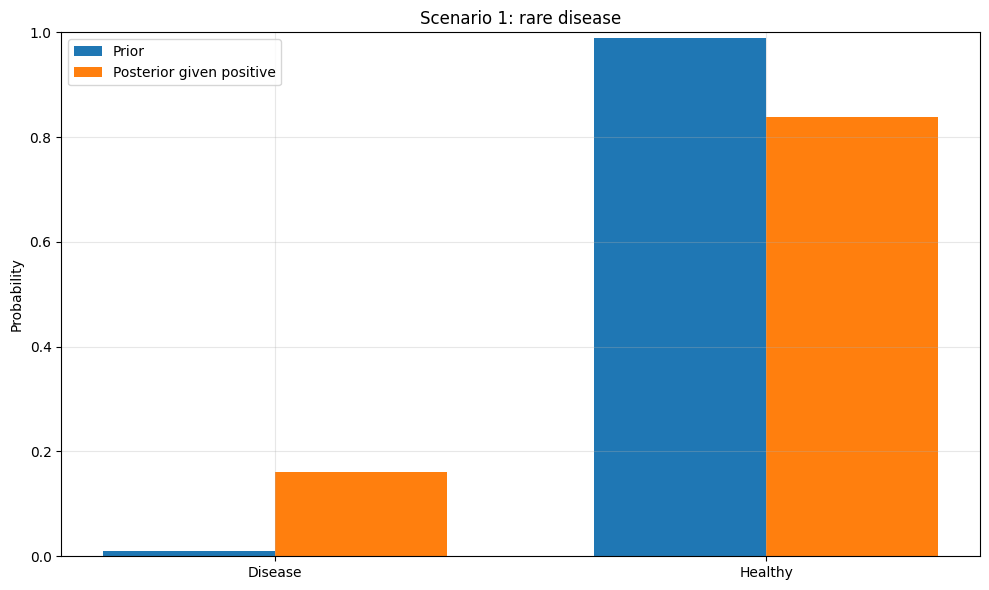

In [ ]:
section_title = "Scenario 1: rare disease"

p_d = 0.01             # P(D)
true_positive = 0.95   # P(+|D)
true_negative = 0.95   # P(-|Dc)

population_size = 25000
seed = 42

run_one_test_analysis(
    section_title=section_title,
    p_d=p_d,
    true_positive=true_positive,
    true_negative=true_negative,
    population_size=population_size,
    seed=seed
)

### Scenario 2: sensitivity vs specificity #1

From this point on, we always keep the same perevalence (prior probability)
$$
P(D)=1\%.
$$

Let's analyze the effect of the sensitivity and specificity.

Before running the next cell
- guess what is more important sensitivity (true positives) or specificity (true negatives).

Scenario 2: higher sensitivity
P(D) = 0.0100
true_positive = 0.9900
true_negative = 0.9500
false_positive = 0.0500
false_negative = 0.0100



,Quantity,Value,Meaning
0,P(D),0.010000,person truly has the disease
1,P(D^c),0.990000,person truly does not have the disease
2,true_positive,0.990000,"test says diseased, and this is true"
3,true_negative,0.950000,"test says healthy, and this is true"
4,false_positive,0.050000,"test says diseased, but person is healthy"
5,false_negative,0.010000,"test says healthy, but person has the disease"
6,P(D|+),0.166667,probability of disease given positive test
7,P(D^c|+),0.833333,probability of no disease given positive test


,Quantity,Value
0,Population size,25000.000000
1,Number diseased,271.000000
2,Number healthy,24729.000000
3,Number positive tests,1496.000000
4,Empirical P(D|+),0.179144
5,Exact P(D|+),0.166667


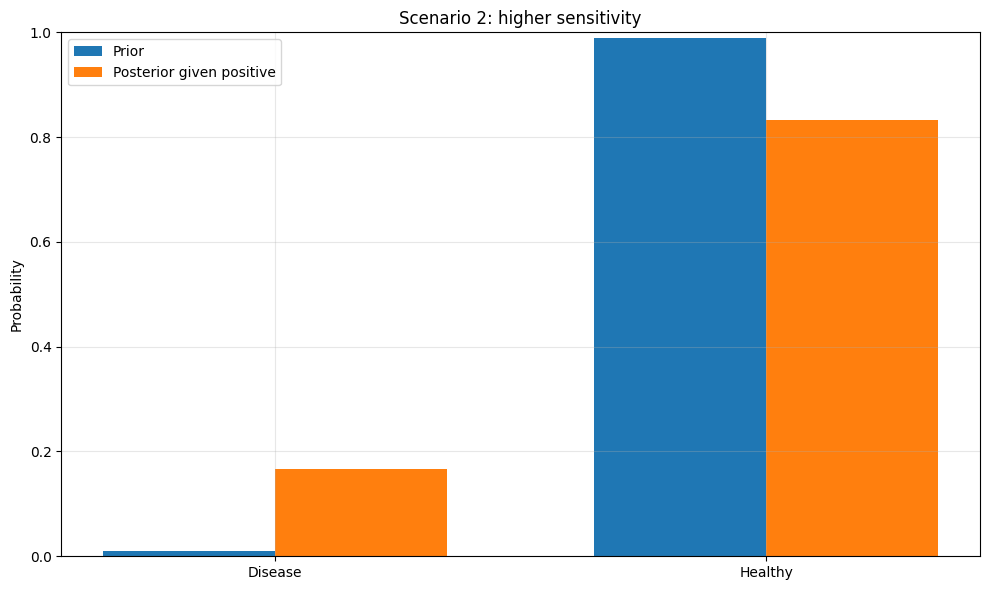

In [ ]:
section_title = "Scenario 2: higher sensitivity"

p_d = 0.01
true_positive = 0.99
true_negative = 0.95

population_size = 25000
seed = 42

run_one_test_analysis(
    section_title=section_title,
    p_d=p_d,
    true_positive=true_positive,
    true_negative=true_negative,
    population_size=population_size,
    seed=seed
)

### Scenario 3: sensitivity vs specificity #2

Now we keep the same prior probability as in Scenario 2, so the comparison becomes cleaner.

Again,

$$
P(D)=1\%.
$$

This time, the test is not as good at finding diseased people, but it is very good at keeping healthy people from getting a positive result.

So now the main question is this: even if the test misses more diseased people, can a positive result still become much more convincing?

Let's think:

- If healthy people rarely get a positive result, what should happen to $P(D \mid +)$?
- For a positive result, which seems more important here: finding more diseased people, or keeping healthy people from getting positive results?
- Compared with Scenario 2, which test should make a positive result more convincing?

Scenario 3: higher specificity
P(D) = 0.0100
true_positive = 0.9500
true_negative = 0.9900
false_positive = 0.0100
false_negative = 0.0500



,Quantity,Value,Meaning
0,P(D),0.010000,person truly has the disease
1,P(D^c),0.990000,person truly does not have the disease
2,true_positive,0.950000,"test says diseased, and this is true"
3,true_negative,0.990000,"test says healthy, and this is true"
4,false_positive,0.010000,"test says diseased, but person is healthy"
5,false_negative,0.050000,"test says healthy, but person has the disease"
6,P(D|+),0.489691,probability of disease given positive test
7,P(D^c|+),0.510309,probability of no disease given positive test


,Quantity,Value
0,Population size,25000.000000
1,Number diseased,271.000000
2,Number healthy,24729.000000
3,Number positive tests,500.000000
4,Empirical P(D|+),0.510000
5,Exact P(D|+),0.489691


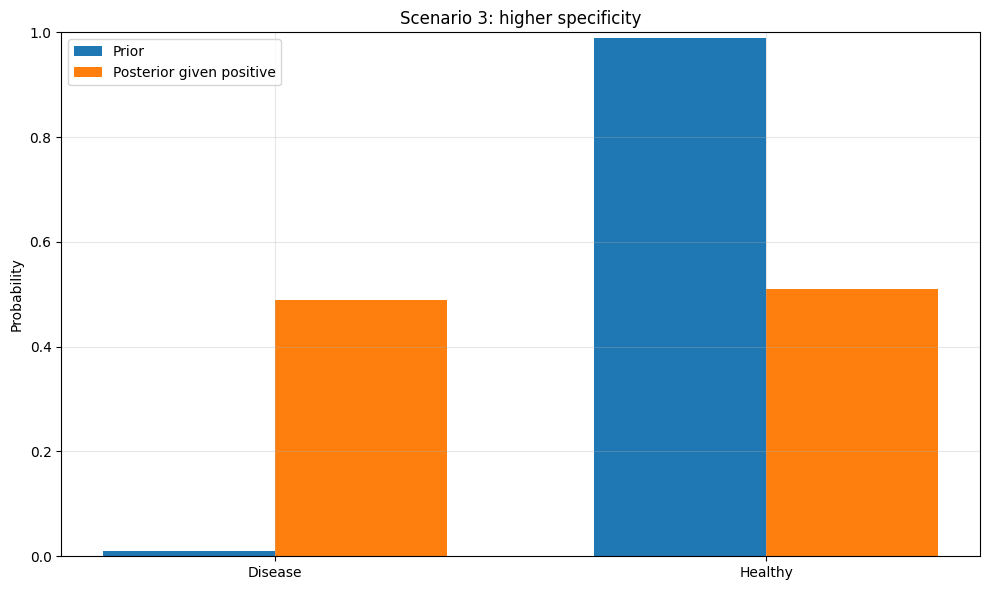

In [ ]:
section_title = "Scenario 3: higher specificity"

p_d = 0.01
true_positive = 0.95
true_negative = 0.99

population_size = 25000
seed = 42

run_one_test_analysis(
    section_title=section_title,
    p_d=p_d,
    true_positive=true_positive,
    true_negative=true_negative,
    population_size=population_size,
    seed=seed
)

### Short discussion after the three scenarios

Now let's observe:

- first compare Scenario 2 and Scenario 3, because they use the same prior probability,
- then compare Scenario 1 with the other two, to see how much a rare disease can change the final answer.

And conclude:

- Between Scenario 2 and Scenario 3, which one gave the more convincing positive result?
- What do Scenario 2 and Scenario 3 suggest about positive results in healthy people?
- Why does Scenario 1 still give a much smaller posterior, even though the test itself looks good?

### What happens with multiple tests?

So far, we used one test. Now we ask a new question: if one positive result is not enough, what happens if the same person takes the test several times?

We assume that, given the person's true disease status, each test is independent of the others.

The main idea is intuitive: if the number of positive results grows, the evidence for disease should become stronger. The calculation will show exactly how fast that happens.

If exactly $k$ out of $n$ tests are positive, then we compute

$$
P(D \mid K = k)
=
\frac{P(K = k \mid D)\,P(D)}
{P(K = k \mid D)\,P(D) + P(K = k \mid D^c)\,P(D^c)}.
$$

Here,

$$
P(K = k \mid D)
=
\binom{n}{k}
(\text{true_positive})^k
(\text{false_negative})^{n-k},
$$

and

$$
P(K = k \mid D^c)
=
\binom{n}{k}
(\text{false_positive})^k
(\text{true_negative})^{n-k}.
$$

Now let's think:

- If a person gets more positive results, should $P(D \mid K = k)$ go up or down?
- In a rare disease case, can repeated positive results overcome a very small prior probability?
- What do you expect when $k = 0$, $k = 1$, ..., $k = n$?

Repeated tests for the rare disease scenario


,k_positive,k_negative,P(K = k | D),P(K = k | D^c),P(D | k positives)
0,0,70,0.000000,0.027584,0.0
1,1,69,0.000000,0.101624,0.0
2,2,68,0.000000,0.184528,0.0
3,3,67,0.000000,0.220139,0.0
4,4,66,0.000000,0.194070,0.0
...,...,...,...,...,...
66,66,4,0.194070,0.000000,1.0
67,67,3,0.220139,0.000000,1.0
68,68,2,0.184528,0.000000,1.0
69,69,1,0.101624,0.000000,1.0


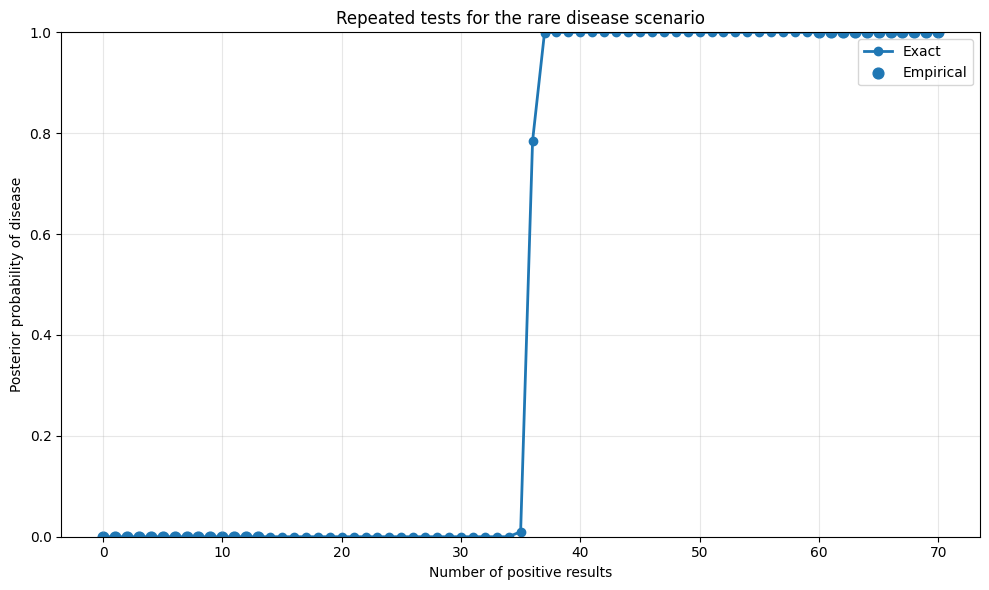

,k_positive,Count in simulation,Empirical P(D | k positives),Exact P(D | k positives)
0,0,682,0.0,0.0
1,1,2577,0.0,0.0
2,2,4557,0.0,0.0
3,3,5472,0.0,0.0
4,4,4757,0.0,0.0
...,...,...,...,...
66,66,51,1.0,1.0
67,67,60,1.0,1.0
68,68,51,1.0,1.0
69,69,21,1.0,1.0


In [ ]:
repeated_title = "Repeated tests for the rare disease scenario"

p_d_rep = 0.01
true_positive_rep = 0.95
true_negative_rep = 0.95

n_tests = 70
population_size_rep = 25000
seed = 42

print(repeated_title)

display(
    repeated_test_table(
        p_d_rep,
        true_positive_rep,
        true_negative_rep,
        n_tests
    ).round(6)
)

repeated_df = plot_repeated_tests(
    p_d_rep,
    true_positive_rep,
    true_negative_rep,
    n_tests=n_tests,
    population_size=population_size_rep,
    seed=seed,
    title=repeated_title
)

display(repeated_df.round(6))

### Plot of $P(D \mid +)$ when one quantity changes

In the earlier sections, we compared only a few separate cases. Now we go one step further.

This time, we keep two values fixed and change only one value continuously. The changing value can be one of these three quantities:

- $P(D)$, the prior probability of disease,
- `true_positive`, the probability that the test gives a positive result when the person really has the disease,
- `true_negative`, the probability that the test gives a negative result when the person is really healthy.

This helps us see how $P(D \mid +)$ changes when only one part of the problem changes.

We also introduce a threshold level $T$. This is a chosen reference value for the posterior probability. We use it to answer a practical question:

**For which values does the positive test become strong enough?**

For example, if we choose

$$
T = 0.5,
$$

then we are asking when

$$
P(D \mid +) \ge 0.5.
$$

In other words, we want to know when a positive result makes the disease at least as likely as not having the disease.

On the graph, we mark the region where

$$
P(D \mid +) \ge T.
$$

Let's guess:

- Which of these three quantities do you think changes $P(D \mid +)$ the most?
- Does increasing $P(D)$ always increase $P(D \mid +)$?
- For a positive result, which seems more important: increasing `true_positive`, or increasing `true_negative`?
- If $T = 0.5$, what does crossing this threshold mean in words?

1D plot for the rare disease scenario


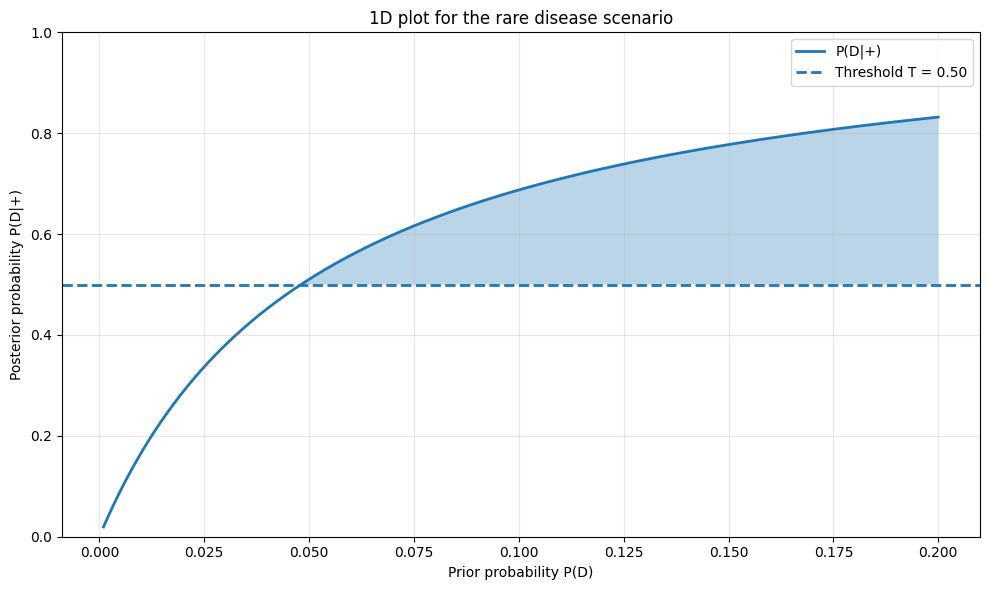

In [ ]:
graph_title = "1D plot for the rare disease scenario"

p_d_graph = 0.01
true_positive_graph = 0.99
true_negative_graph = 0.95

variable_name = "P(D)"      # choose: "P(D)", "true_positive", "true_negative"
threshold = 0.50

print(graph_title)

plot_posterior_1d(
    variable_name=variable_name,
    p_d=p_d_graph,
    true_positive=true_positive_graph,
    true_negative=true_negative_graph,
    threshold=threshold,
    title=graph_title
)

### Plot of $P(D \mid +)$ when two quantities change

Finally, we let two quantities change at the same time, while the third one stays fixed.

The two changing quantities are chosen from:

- $P(D)$,
- `true_positive`,
- `true_negative`.

This gives a 3D surface for $P(D \mid +)$. The goal is to see how two parts of the problem work together. A convincing positive result usually does not come from only one good value. It usually comes from a good combination of values.

We again use a threshold level $T$. This is a target level for the posterior probability.

For example, if

$$
T = 0.5,
$$

then we are asking:

**When does a positive result make the disease at least as likely as not having the disease?**

So we draw the threshold plane

$$
z = T,
$$

and look for the part of the surface that lies above it.

### But...

When the disease is very rare, for example when $P(D)=0.01$, the threshold $T=0.5$ may be reached only in a very small part of the graph. So if the visible region above the plane looks very small, this does **not** mean that the code is wrong.

It means something important: when the disease is very rare, it is hard for one positive test to make the disease more likely than not unless the test is extremely strong.

Again, let's guess:

- Which combinations push $P(D \mid +)$ above the threshold?
- Is a high `true_positive` alone enough, or do we also need a high `true_negative`?
- Why can the region above $T=0.5$ become very small when the disease is rare?

3D plot for the rare disease scenario


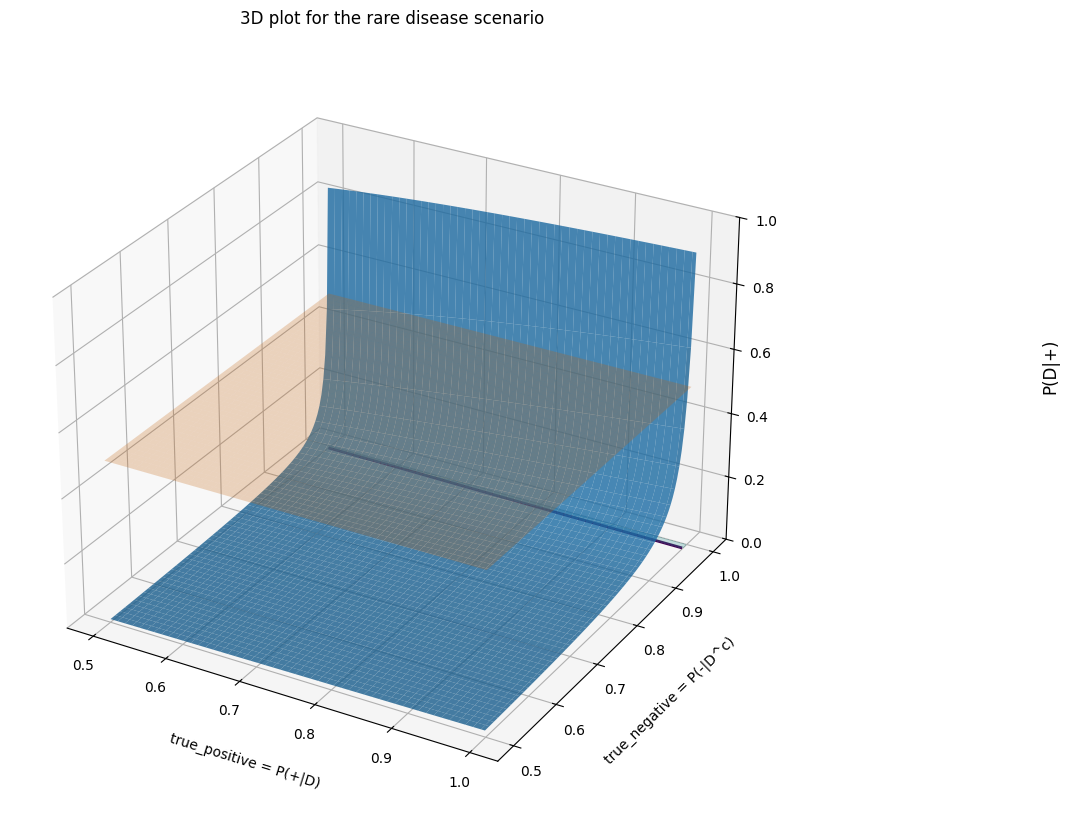

In [ ]:
plot3d_title = "3D plot for the rare disease scenario"

p_d_3d = 0.01
true_positive_3d = 0.99
true_negative_3d = 0.95

fixed_parameter = "P(D)"    # choose: "P(D)", "true_positive", "true_negative"

# With a very rare disease and T = 0.50
# the region above the threshold may be very small
# This is an important result, not a plotting error
threshold = 0.50

print(plot3d_title)

plot_posterior_3d(
    fixed_parameter=fixed_parameter,
    p_d=p_d_3d,
    true_positive=true_positive_3d,
    true_negative=true_negative_3d,
    threshold=threshold,
    title=plot3d_title
)